In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import pandas as pd
import numpy as np
from PIL import Image
from omegaconf import OmegaConf

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from brokenaxes import brokenaxes
# from curve_utils import plot_one_image_curve

In [3]:

import random
import string
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D
from curve_utils import get_all_curves, pick_same_index_across_lists


In [4]:

from plotting_helpers import make_publication_legend
import matplotlib.patches as mpatches


In [5]:

color_groups = {
    'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
    'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
    'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
}
new_names = {
    'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
    'resnet_imagenet': 'ResNet INet', 'nako_mae': "MAE NAKO", 'simclr_nako': 'SimCLR NAKO',
    'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': "ResNet Scratch"
}
info_dict = [
        {'freeze_encoder': 1, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 1, 'train_size': 30000, 'has_event': False},

        {'freeze_encoder': 0, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 0, 'train_size': 30000, 'has_event': True},

            ]

## Prelim

In [6]:
project_dir = '/gpfs01/berens/user/inwabufo/leverage/leverage-data'
from omegaconf import OmegaConf

CLEANED_FILE = 'areds_new_results_cleaned_03_06_26_split_id_11042026.csv'
metadata_dir = os.path.join(project_dir, 'metadata')
log_dir = 'log_dir'
hostname_ = 'CIN'
dataset_name = 'areds_new'
split_id = 11042026

config_file = '/gpfs01/berens/user/inwabufo/.secrets.yaml'
cfg = OmegaConf.load(config_file)
stylef = cfg['stylef'][hostname_]
CHKPT_DIR = chkpt_dir = os.path.join(project_dir, 'chkpt_dir', 'npj_areds_curves')
RESULTS_DIR = os.path.join(project_dir, 'results')
project_dir = cfg['DATASETS'][hostname_][dataset_name]
stylef = cfg['stylef'][hostname_]
img_dir = f"{project_dir}"
img_dir

'/gpfs01/berens/user/inwabufo/data/AREDS/AREDS_macula'

In [7]:
!ls /gpfs01/berens/data/data/medical_imaging/areds/


areds_dataset_mnistlike  mask_fails
areds_parse.py		 metadata
areds_preprocess.py	 miccai24_patches_exported
data_processed		 mlcloud_data_to_scratch.sh
data_use_agreements	 outdated
environment.yml		 __pycache__
examples		 quality_fit.csv
extract_images.sh	 Readme.md
extract_metadata.sh	 resize_f2_imgs.py
fundus_tools		 sratoolkit.3.0.0-centos_linux64
images-f2-1024px	 src
images-f2-512px		 wandb


In [8]:
cfg['DATASETS'][hostname_]['areds_original']

'/gpfs01/berens/data/data/medical_imaging/areds/images-f2-512px'

In [9]:
!ls /gpfs01/berens/data/data/medical_imaging/areds/

areds_dataset_mnistlike  mask_fails
areds_parse.py		 metadata
areds_preprocess.py	 miccai24_patches_exported
data_processed		 mlcloud_data_to_scratch.sh
data_use_agreements	 outdated
environment.yml		 __pycache__
examples		 quality_fit.csv
extract_images.sh	 Readme.md
extract_metadata.sh	 resize_f2_imgs.py
fundus_tools		 sratoolkit.3.0.0-centos_linux64
images-f2-1024px	 src
images-f2-512px		 wandb


In [10]:
or_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}'))
print(or_df.shape)
or_df.head(2)

(1120, 71)


,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


In [11]:
metadata_dir

'/gpfs01/berens/user/inwabufo/leverage/leverage-data/metadata'

In [12]:
metadata_df = pd.read_csv(os.path.join(metadata_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()

patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(metadata_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
# get the test set
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)
test.head()

/tmp/ipykernel_917248/3305201377.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(os.path.join(metadata_dir,'surv_jul_data0_11_04_26.csv'))


,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1006,1006_left,1006_left_RS_04,4,left,F2,RS,55353_04_F2_LE_RS.jpg,55353/55353_04_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,69.3,1006_left,1006_left_4,18,0
1,1006,1006_left,1006_left_LS_06,6,left,F2,LS,55353_06_F2_LE_LS.jpg,55353/55353_06_F2_LE_LS.jpg,2.0,...,4.0,N,N,14.0,N,70.3,1006_left,1006_left_6,16,0
2,1006,1006_left,1006_left_RS_08,8,left,F2,RS,55353_08_F2_LE_RS.jpg,55353/55353_08_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,71.3,1006_left,1006_left_8,14,0
3,1006,1006_left,1006_left_RS_10,10,left,F2,RS,55353_10_F2_LE_RS.jpg,55353/55353_10_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,72.2,1006_left,1006_left_10,12,0
4,1006,1006_left,1006_left_RS_12,12,left,F2,RS,55353_12_F2_LE_RS.jpg,55353/55353_12_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,73.2,1006_left,1006_left_12,10,0


In [13]:
test['patient_id'] = test['patient_id'].astype(str)

In [14]:
def get_patient_panel(or_df, test, row_idx, freeze_encoder, train_size, has_event, CHKPT_DIR):
    """
    Pulls the full trajectory for one patient (num_images=None -> all visits),
    then keeps only ONE panel:
      - converter: the pre-conversion visit (marker_panel_idx), with marker_x set
      - non-converter: a fixed reference visit (index 2, i.e. 3rd visit) for
        rough visual comparability across panels, no marker
    """
    dict1, img_to_plot, train_size_returned = plot_one_image_curve(
        or_df, test, freeze_encoder=freeze_encoder, train_size=train_size,
        num_images=None, has_event=has_event, CHKPT_DIR=CHKPT_DIR,
        to_plot_row_index=row_idx
    )

    grades = img_to_plot['diagnosis_amd_grade']
    visit_number = [int(v / 2) for v in img_to_plot['visit_number']]

    marker_x = None
    is_conversion = False

    if any(g in [10, 11, 12] for g in grades):
        first_conversion_idx = next((i for i, g in enumerate(grades) if g >= 10), None)
        panel_idx = max(first_conversion_idx - 2, 0)          # pre-conversion visit
        marker_x = visit_number[first_conversion_idx] - visit_number[panel_idx]
        is_conversion = True
    else:
        panel_idx = min(2, len(grades) - 1)                    # fixed reference visit

    model_curves = {model: curves[panel_idx] for model, curves in dict1.items()}

    return {
        'patient_id': img_to_plot['patient_id'][panel_idx],
        'image_path': img_to_plot['image_path'][panel_idx],
        'diagnosis_amd_grade': grades[panel_idx],
        'visit_number': visit_number[panel_idx],
        'marker_x': marker_x,
        'is_conversion': is_conversion,
        'train_size': train_size_returned,
        'curves': model_curves,
    }
def get_event_sample(test, has_event=True, n_img=5):
    """Selects candidate patients based on has_event, independent of model config."""
    test = test.copy()
    test['converter'] = test['diagnosis_amd_grade'].apply(lambda x: x in [10, 11, 12])
    test_grp = test.sort_values(['visit_number']).groupby(['eye_id', 'image_eye']).agg(list)
    test_grp['n_img'] = test_grp['image_side'].apply(lambda x: len(x))
    test_grp['has_event'] = test_grp['event'].apply(lambda x: 1 in x)

    sample_ = test_grp[(test_grp['n_img'] == n_img) &
                        (test_grp['has_event'] == has_event)].reset_index(drop=False)
    return sample_

In [15]:

# import string
# from matplotlib.lines import Line2D
from plotting_helpers import make_publication_legend_columns  # adjust import path as needed

def draw_patient_grid(records, image_dir=None, n_cols=4,
                       save_path=None, stylef=None, save_name=None,
                       legend_bbox_to_anchor=(0.5, -0.05),
                       text_x = -0.15, text_y = 1.08, show_title = True  ):
    color_groups = {
        'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
        'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
        'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
    }
    new_names = {
        'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
        'resnet_imagenet': 'ResNet INet', 'nako_mae': 'MAE NAKO', 'simclr_nako': 'SimCLR NAKO',
        'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': 'ResNet Scratch',
    }
    model_groups = {
        'dino_nako': 'in-domain FM', 'dino_meta': 'out-of-domain FM', 'retfound': 'in-domain FM',
        'mae_nako': 'in-domain PR', 'simclr_INet_nako': 'in-domain PR', 'simclr_nako': 'in-domain PR',
        'resnet_scratch': 'supervised BS', 'resnet_INet': 'supervised BS',
    }
    group_colors = {
        'supervised BS': '#1565C0', 'out-of-domain FM': '#05771D',
        'in-domain PR': '#6A1B9A', 'in-domain FM': '#050606',
    }
    group_shades = {
        'supervised BS': ['#1565C0', '#42A5F5'], 'out-of-domain FM': ['#05771D'],
        'in-domain PR': ['#6A1B9A', '#D81B60', '#F3D0DC'], 'in-domain FM': ['#000000', '#90A4AE'],
    }
    group_members = {}
    for model, group in model_groups.items():
        group_members.setdefault(group, []).append(model)
    for group in group_members:
        group_members[group] = sorted(group_members[group])
    model_colors = {}
    for group, members in group_members.items():
        shades = group_shades[group]
        for i, model in enumerate(members):
            model_colors[model] = shades[i % len(shades)]
    cm_colors = {}
    for model, color in model_colors.items():
        cm_colors[model + '_lin'] = color
        cm_colors[model + '_mlp'] = color

    n_patients = len(records)
    y_min = min(min(curve) for r in records for curve in r['curves'].values()) - 0.02
    y_max = 1
    x_max = max(len(next(iter(r['curves'].values()))) for r in records)

    show_images = image_dir is not None
    # CHANGED: always reserve an image row (row 1) when show_images is True
    n_rows_layout = 2 if show_images else 1
    height_ratios = [3, 1] if show_images else [1]

    style_ctx = stylef if stylef is not None else 'default'
    

    with plt.style.context(style_ctx):
        # fig = plt.figure(figsize=(n_cols * 3.2, 3.8 * n_rows_layout))
        fig = plt.figure(figsize=(n_cols * 3.2, 2.5 * n_rows_layout))

        gs = gridspec.GridSpec(
            n_rows_layout, n_cols, figure=fig,
            wspace=0.35, hspace=0.35, height_ratios=height_ratios
        )

        for p, rec in enumerate(records):
            bax = brokenaxes(
                xlims=((0.05, 0.002), (0.95, x_max + 0.1)),
                width_ratios=[0.05, 1],
                hspace=0.001, d=0.003, tilt=45,
                subplot_spec=gs[0, p], fig=fig
            )
            for line in bax.diag_handles:
                line.set_linewidth(1.5)

            panel_letter = string.ascii_uppercase[p]
            bax.axs[0].text(text_x, text_y, panel_letter, #transform=bax.axs[0].transAxes,
                             fontsize=10, fontweight='bold', va='top', ha='left', clip_on=False)

            for model, curve in rec['curves'].items():
                bax.plot(range(1, len(curve) + 1), curve,
                          label=new_names.get(model, model),
                          color=color_groups.get(model), linewidth=2)

            if rec.get('is_conversion') and rec.get('marker_x') is not None:
                bax.axs[1].plot(rec['marker_x'], 0.02, marker='v', markersize=10,
                                 color='grey', linestyle='none', clip_on=False, zorder=5)
            if show_title:
                bax.set_title(f"pID {rec['patient_id']} tr {rec['train_size']}\n"
                          f"V_no {rec['visit_number']} Label {int(rec['diagnosis_amd_grade'])}",
                          fontsize=10)
            bax.set_ylim(y_min, y_max)
            if p == 0:
                bax.set_ylabel('S(t)', fontsize=10)

            bax.axs[0].set_xticks([])
            bax.axs[1].set_xticks(range(1, x_max + 2))
            for ax in bax.axs:
                ax.tick_params(axis='both', labelsize=10, width=1, length=5)
                ax.set_yticks([0, 0.5, 1.0])
                for spine in ['left', 'bottom']:
                    ax.spines[spine].set_linewidth(1.5)

            # ── image row directly below this panel ─────────────────────
            if show_images:
                ax_img = fig.add_subplot(gs[1, p])
                try:
                    img_path = os.path.join(image_dir, f"R_{rec['image_path']}")
                    ax_img.imshow(mpimg.imread(img_path))
                except Exception as e:
                    print(f"Could not load image {rec['image_path']}: {e}")
                ax_img.axis('off')

        # ── multi-column legend, placed BELOW the entire grid (incl. images) ──
        proxy_mlp = Line2D([0], [0], linestyle='-',  color='gray', linewidth=2, label='MLP head')
        proxy_lin = Line2D([0], [0], linestyle='--', color='gray', linewidth=2, label='Linear head')

        group_columns = make_publication_legend_columns(cm_colors, model_groups, group_colors)

        head_column = (
            [Line2D([0], [0], color='none'), proxy_mlp, proxy_lin],
            ['Head type', 'MLP head', 'Linear head'],
            ['Head type', None, None],
        )

        conversion_column = (
            [Line2D([0], [0], color='none'),
             Line2D([0], [0], marker='v', color='w', markerfacecolor='grey',
                    markersize=8, linestyle='none')],
            ['', 'Conversion'],
            [None, None],
        )

        all_columns = [head_column] + group_columns + [conversion_column]
        max_rows = max(len(h) for h, l, r in all_columns)

        flat_handles, flat_labels, flat_raw = [], [], []
        for handles, labels, raw in all_columns:
            pad = max_rows - len(handles)
            handles = handles + [Line2D([0], [0], color='none')] * pad
            labels  = labels  + [''] * pad
            raw     = raw     + [None] * pad
            flat_handles.extend(handles)
            flat_labels.extend(labels)
            flat_raw.extend(raw)

        combined_legend = fig.legend(
            handles=flat_handles,
            labels=flat_labels,
            loc='upper center',
            bbox_to_anchor=legend_bbox_to_anchor,   # CHANGED: figure-relative, below images
            bbox_transform=fig.transFigure,
            ncol=len(all_columns),
            fontsize=10,
            edgecolor='#cccccc',
            frameon=False,
            handlelength=2.0,
            handletextpad=0.5,
            columnspacing=1.5,
             handler_map={Line2D: HandlerLine2D(numpoints=3)}
        )

        for text, raw_label in zip(combined_legend.get_texts(), flat_raw):
            if raw_label is not None:
                text.set_fontweight('bold')

    fig.supxlabel('Years', fontsize=10, x=0.51, y=0.3)
    if save_path is not None:
        fname = save_name or 'patient_grid'
        # CHANGED: bbox_inches='tight' so the below-image legend isn't clipped
        plt.savefig(f'{save_path}/{fname}.pdf', bbox_inches='tight', dpi =300)
    plt.show()
def plot_one_image_curve(or_df, test, freeze_encoder = 1, train_size = 30000, 
                         num_images = None, has_event = True, CHKPT_DIR = '', 
                         to_plot_row_index = None, patient_id = None):

    """
    num_images: determines how many images per patient would be shown
    
    """
    dfl = or_df[(or_df['freeze_encoder'] == freeze_encoder) & (or_df['survival_head'] == 'mlp') & (or_df['train_size'] == train_size)]
    dfl_ssl = dfl.groupby(['weights_path']).agg(list)

    dfl_ssl['model'] = dfl_ssl['summary'].apply(lambda x: x[0])
    model_list = sorted(list(dfl_ssl['model'].unique()))
    # print('model list',model_list)
    dfl_ssl['best_idx'] = dfl_ssl['test/ibs'].apply(lambda x: np.argmin(np.array(x)) )

    dfl_ssl['best_result'] = dfl_ssl.apply(lambda row: row['Name'][row['best_idx']], axis=1)
    dfl_ssl['best_result'].head()

    test['converter'] = test['diagnosis_amd_grade'].apply(lambda x: x in [10, 11, 12])
    test_grp = test.sort_values(['visit_number']).groupby(['eye_id', 'image_eye']).agg(list)
    test_grp['n_img'] = test_grp['image_side'].apply(lambda x: len(x))
    test_grp['n_img'].value_counts()

    test_grp['has_event'] = test_grp['event'].apply(lambda x: 1 in x)
    test_grp['has_event'].value_counts()

    # print(test_grp.columns)

    sample_ = test_grp[(test_grp['n_img'] == 5) & (test_grp['has_event'] == has_event)].reset_index(drop = False)
    # print('sample', sample_[['patient_id', 'visit_number', 'converter', 'has_event', 'diagnosis_amd_grade', 'image_path']])
    if patient_id is not None:
        matches = sample_.index[sample_['patient_id'].apply(lambda x: x[0] if isinstance(x, list) else x) == patient_id].tolist()
        if not matches:
            raise ValueError(f"patient_id {patient_id} not found in filtered sample_ (freeze_encoder={freeze_encoder}, train_size={train_size}, has_event={has_event})")
        to_plot_row_index = matches[0]
    elif to_plot_row_index is None:
        to_plot_row_index = random.randint(0, (len(sample_) - 1))

    # if to_plot_row_index is None:
    #     to_plot_row_index = random.randint(0,(len(sample_)-1))
    # print('to_plot_row_index is', to_plot_row_index)
    
    # selects all the images related to an ID. The row from the dataframe is determined by to_plot_row_index
    all_images_to_plot =  sample_.loc[to_plot_row_index, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number", "converter"]]
    all_images_to_plot['train_size'] = train_size
    # print('all_images_to_plot', all_images_to_plot.shape)
    # print('all_images_to_plot', all_images_to_plot)

    # of ID of a person, determined how many images to plot
    all_images_to_plot = pick_same_index_across_lists(all_images_to_plot, num_images = num_images)

    # print('--------------------------------------')
    # print()
    # print(all_images_to_plot)
    # print('--------------------------------------')
    # print()
    curves_dict ={}

    curves_dict = get_all_curves(all_images_to_plot, model_list, dfl_ssl, CHKPT_DIR)
    return curves_dict, all_images_to_plot, train_size

In [ ]:
n_with_event = 3
n_without_event = 1

sample_event = get_event_sample(test, has_event=True, n_img=5).reset_index()
sample_no_event = get_event_sample(test, has_event=False, n_img=5).reset_index()

event_row_indices = random.sample(range(len(sample_event)), n_with_event)
no_event_row_indices = random.sample(range(len(sample_no_event)), n_without_event)

In [ ]:
no_event_row_indices, event_row_indices #([118], [0, 11, 16])

([118], [0, 11, 16])

In [ ]:


# Fixed model config used for all 4 patients (pick whichever combo you want to showcase)
freeze_encoder = 1
train_size = 30000

records = []

for row_idx in event_row_indices:
    records.append(get_patient_panel(or_df, test, row_idx, freeze_encoder,
                                       train_size, has_event=True, CHKPT_DIR=CHKPT_DIR))

for row_idx in no_event_row_indices:
    records.append(get_patient_panel(or_df, test, row_idx, freeze_encoder,
                                       train_size, has_event=False, CHKPT_DIR=CHKPT_DIR))

# random.shuffle(records)   # optional: so the converter isn't always panel A

                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_30000_mlp_2026-06-08_11...   
dino_nako     [testrun_False_FE_True_30000_mlp_2026-06-08_14...   
nako_mae      [testrun_False_FE_True_30000_mlp_2026-06-10_10...   

                                                          State  \
weights_path                                                      
dino_meta     [finished, finished, finished, finished, finis...   
dino_nako     [finished, finished, finished, finished, finis...   
nako_mae      [finished, finished, finished, finished, finis...   

                        Notes                       User  \
weights_path                                               
dino_meta     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
dino_nako     [-, -, -, -, -]  [nan, nan, nan, nan, nan]   
nako_mae      [-, -, -, -, -]  [nan, nan, nan, nan, nan]   

                           

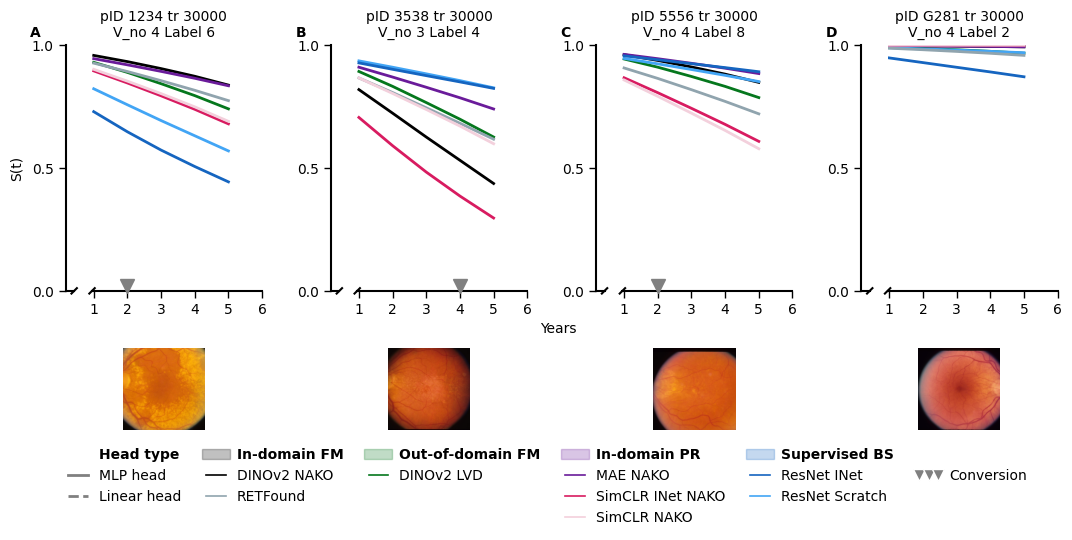

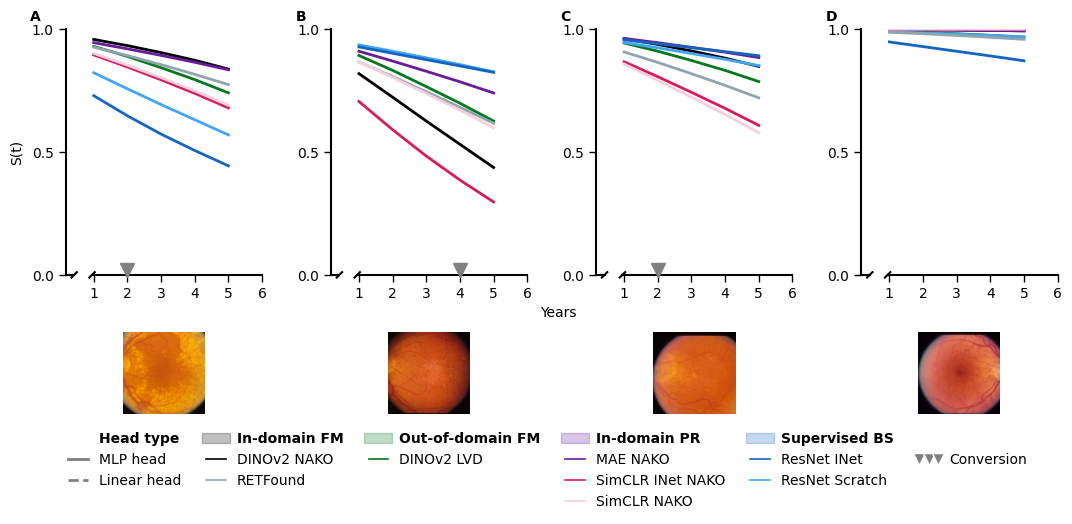

In [38]:
draw_patient_grid(records, image_dir=img_dir, n_cols=4,
                  legend_bbox_to_anchor=(0.5, 0.10),  text_y=1.08,
                                          text_x = 0.25,show_title=True)   # curves only
draw_patient_grid(records, image_dir=img_dir, n_cols=4,
                  legend_bbox_to_anchor=(0.5, 0.10),  text_y=1.08,
                                          text_x = 0.25,show_title=False, 
                                          save_path=RESULTS_DIR)   # curves only


In [39]:
# draw_patient_grid(records, image_dir=img_dir, n_cols=4,
#                   legend_bbox_to_anchor=(0.5, 0.10),  text_y=1.08,
#                                           text_x = 0.25,)   # curves only


In [40]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# def draw_patient_grid(records, image_dir=None, n_cols=4,
#                        save_path=None, stylef=None, save_name=None,
#                        legend_bbox_to_anchor=(1.02, 0.5)):
#     color_groups = {
#         'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
#         'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
#         'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
#     }
#     new_names = {
#         'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
#         'resnet_imagenet': 'ResNet INet', 'nako_mae': 'MAE NAKO', 'simclr_nako': 'SimCLR NAKO',
#         'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': 'ResNet Scratch',
#     }
#     model_groups = {
#         'dino_nako': 'in-domain FM', 'dino_meta': 'out-of-domain FM', 'retfound': 'in-domain FM',
#         'mae_nako': 'in-domain PR', 'simclr_INet_nako': 'in-domain PR', 'simclr_nako': 'in-domain PR',
#         'resnet_scratch': 'supervised BS', 'resnet_INet': 'supervised BS',
#     }
#     group_colors = {
#         'supervised BS': '#1565C0', 'out-of-domain FM': '#05771D',
#         'in-domain PR': '#6A1B9A', 'in-domain FM': '#050606',
#     }
#     group_shades = {
#         'supervised BS': ['#1565C0', '#42A5F5'], 'out-of-domain FM': ['#05771D'],
#         'in-domain PR': ['#6A1B9A', '#D81B60', '#F3D0DC'], 'in-domain FM': ['#000000', '#90A4AE'],
#     }
#     group_members = {}
#     for model, group in model_groups.items():
#         group_members.setdefault(group, []).append(model)
#     for group in group_members:
#         group_members[group] = sorted(group_members[group])
#     model_colors = {}
#     for group, members in group_members.items():
#         shades = group_shades[group]
#         for i, model in enumerate(members):
#             model_colors[model] = shades[i % len(shades)]
#     cm_colors = {}
#     for model, color in model_colors.items():
#         cm_colors[model + '_lin'] = color
#         cm_colors[model + '_mlp'] = color

#     n_patients = len(records)
#     y_min = min(min(curve) for r in records for curve in r['curves'].values()) - 0.02
#     y_max = 1
#     x_max = max(len(next(iter(r['curves'].values()))) for r in records)

#     show_images = image_dir is not None
#     n_rows_layout = 2 if show_images else 1
#     height_ratios = [3, 1] if show_images else [1]

#     style_ctx = stylef if stylef is not None else 'default'

#     with plt.style.context(style_ctx):
#         fig = plt.figure(figsize=(n_cols * 3.2, 3.8 * n_rows_layout))
#         gs = gridspec.GridSpec(
#             n_rows_layout, n_cols, figure=fig,
#             wspace=0.35, hspace=0.25, height_ratios=height_ratios
#         )

#         for p, rec in enumerate(records):
#             bax = brokenaxes(
#                 xlims=((0.05, 0.002), (0.95, x_max + 0.1)),
#                 width_ratios=[0.05, 1],
#                 hspace=0.001, d=0.003, tilt=45,
#                 subplot_spec=gs[0, p], fig=fig
#             )
#             for line in bax.diag_handles:
#                 line.set_linewidth(1.2)

#             panel_letter = string.ascii_uppercase[p]
#             bax.axs[0].text(-0.15, 1.08, panel_letter, transform=bax.axs[0].transAxes,
#                              fontsize=13, fontweight='bold', va='top', ha='left')

#             for model, curve in rec['curves'].items():
#                 bax.plot(range(1, len(curve) + 1), curve,
#                           label=new_names.get(model, model),
#                           color=color_groups.get(model), linewidth=1.5)

#             if rec.get('is_conversion') and rec.get('marker_x') is not None:
#                 bax.axs[1].plot(rec['marker_x'], 0.02, marker='v', markersize=10,
#                                  color='grey', linestyle='none', clip_on=False, zorder=5)

#             bax.set_title(f"pID {rec['patient_id']} tr {rec['train_size']}\n"
#                           f"V_no {rec['visit_number']} Label {int(rec['diagnosis_amd_grade'])}",
#                           fontsize=10)
#             bax.set_ylim(y_min, y_max)
#             if p == 0:
#                 bax.set_ylabel('Risk', fontsize=10)
#             bax.axs[0].set_xticks([])
#             bax.axs[1].set_xticks(range(1, x_max + 2))
#             for ax in bax.axs:
#                 ax.tick_params(axis='both', labelsize=10, width=1, length=5)
#                 ax.set_yticks([0, 0.5, 1.0])
#                 for spine in ['left', 'bottom']:
#                     ax.spines[spine].set_linewidth(1)

#             if show_images:
#                 ax_img = fig.add_subplot(gs[1, p])
#                 try:
#                     img_path = os.path.join(image_dir, f"R_{rec['image_path']}")
#                     ax_img.imshow(mpimg.imread(img_path))
#                 except Exception as e:
#                     print(f"Could not load image {rec['image_path']}: {e}")
#                 ax_img.axis('off')

#         # ── single legend, once, on the right ──────────────────────
#         handles, display_labels, raw_labels = make_publication_legend(
#             ax=bax, cm_colors=cm_colors, model_groups=model_groups,
#             group_colors=group_colors, return_handles=True
#         )
#         handles.append(Line2D([0], [0], marker='v', color='w',
#                                markerfacecolor='grey', markersize=8, linestyle='none'))
#         display_labels.append('Conversion')
#         raw_labels.append('  conversion')

#         leg = fig.legend(
#             handles, display_labels, loc='center left',
#             bbox_to_anchor=legend_bbox_to_anchor, bbox_transform=fig.transFigure,
#             ncol=1, frameon=False, framealpha=0.95, edgecolor='#cccccc',
#             fontsize=8, handlelength=2.0, handleheight=1.0, handletextpad=0.5,
#             borderpad=0.8, labelspacing=0.3, handler_map={Line2D: HandlerLine2D(numpoints=3)}
#         )
#         for text, raw_label in zip(leg.get_texts(), raw_labels):
#             if not raw_label.startswith('  ') and raw_label != '':
#                 text.set_fontweight('bold')
#         for line in leg.get_lines():
#             line.set_linewidth(1.5)

#     if save_path is not None:
#         fname = save_name or 'patient_grid'
#         plt.savefig(f'{save_path}/{fname}.pdf', bbox_inches='tight')
#     plt.show()